# Model soortenrijkdom

## Packages inladen

In [ ]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    train_test_split, cross_val_score, GroupKFold,
)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")

## Data inladen 

### Dataframe van Aquamaps en Bio-ORACLE

Deze data is afkomstig van Aquamaps

In [2]:
df_env = pd.read_csv("Data/Diversity_data_with_env.csv")
print(f"env data:             {df_env.shape}")
df_env.head()

env data:             (2452, 33)


,grid_id,long,lat,marine_species_richness,PD,co1_genetic_diversity_mean,long_deg,lat_deg,long_dd,lat_dd,...,Shelf,Slope,Abyssal,TidalRange,Coral,Estuary,Seamount,MPA,matched_CenterLong,matched_CenterLat
0,1,-17174579,-7123536,44,11.830844,0.007171,-171.74579,-71.23536,-171.74579,-71.23536,...,0.0,730.228795,263.361205,-9999.0,0.0,0.0,0,NaN,-171.75,-71.25
1,2,-16788679,-7123536,43,11.830844,0.007171,-167.88679,-71.23536,-167.88679,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-167.75,-71.25
2,3,-16402779,-7123536,44,12.650381,0.007499,-164.02779,-71.23536,-164.02779,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-164.25,-71.25
3,4,-16016879,-7123536,44,12.650381,0.007499,-160.16879,-71.23536,-160.16879,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-160.25,-71.25
4,5,-15630979,-7123536,45,12.650381,0.007499,-156.30979,-71.23536,-156.30979,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-156.25,-71.25


Deze data is afkomstig van Bio-ORACLE

In [3]:
df_biooracle = pd.read_csv("Data/Diversity_data_with_biooracle_2010.csv")
print(f"biooracle data:       {df_biooracle.shape}")
df_biooracle.head()

biooracle data:       (2452, 75)


,marine_species_richness,PD,co1_genetic_diversity_mean,long_deg,lat_deg,chl_max,chl_mean,chl_min,clt_max,clt_mean,...,terrain_characteristics_bea_min,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_ltmax,T_ltmin,T_max,T_mean,T_min,T_range
0,44,11.830844,0.007171,-171.74579,-71.23536,1.987486,0.264222,0.015311,0.993542,0.681597,...,-3883.0,66.347260,0.933108,6.854279,-0.711044,-1.904281,-0.127859,-1.602750,-1.977225,1.849366
1,43,11.830844,0.007171,-167.88679,-71.23536,2.205368,0.278952,0.015232,0.961121,0.693978,...,-4084.0,21.055542,0.320794,-12.930603,-0.847708,-1.925544,-0.017505,-1.620118,-2.000000,1.988636
2,44,12.650381,0.007499,-164.02779,-71.23536,1.891105,0.270836,0.015052,0.960210,0.698352,...,-4153.0,14.489563,0.228825,5.524109,-0.521772,-1.923338,0.125601,-1.582915,-2.000000,2.137620
3,44,12.650381,0.007499,-160.16879,-71.23536,1.963815,0.293940,0.015424,0.962838,0.693123,...,-4303.0,4.413208,0.081748,1.760254,-0.558407,-1.909406,-0.032617,-1.579760,-1.976150,1.943533
4,45,12.650381,0.007499,-156.30979,-71.23536,1.956123,0.298378,0.015726,0.969080,0.688964,...,-4341.0,10.302124,0.234018,-0.892456,-0.570859,-1.906482,-0.000029,-1.570748,-2.000000,2.001978


### Variabelen bekijken

In [4]:
df_biooracle.columns

Index(['marine_species_richness', 'PD', 'co1_genetic_diversity_mean',
       'long_deg', 'lat_deg', 'chl_max', 'chl_mean', 'chl_min', 'clt_max',
       'clt_mean', 'clt_min', 'currentdirection_max', 'currentdirection_mean',
       'currentdirection_min', 'currentvelocity_ltmax', 'currentvelocity_max',
       'currentvelocity_mean', 'currentvelocity_min', 'dfe_max', 'dfe_mean',
       'dfe_min', 'kdpar_max', 'kdpar_mean', 'kdpar_min', 'mlotst_max',
       'mlotst_mean', 'mlotst_min', 'no3_max', 'no3_mean', 'no3_min', 'o2_max',
       'o2_mean', 'o2_min', 'par_mean', 'par_min', 'phyc_max', 'phyc_mean',
       'phyc_min', 'ph_max', 'ph_mean', 'ph_min', 'po4_max', 'po4_mean',
       'po4_min', 'salinity_ltmax', 'salinity_ltmin', 'salinity_max',
       'salinity_mean', 'salinity_min', 'salinity_range', 'siconc_max',
       'siconc_mean', 'siconc_min', 'sithick_max', 'sithick_mean',
       'sithick_min', 'si_max', 'si_mean', 'si_min', 'tas_max', 'tas_mean',
       'tas_min', 'terrain_charact

In [5]:
df_env.columns

Index(['grid_id', 'long', 'lat', 'marine_species_richness', 'PD',
       'co1_genetic_diversity_mean', 'long_deg', 'lat_deg', 'long_dd',
       'lat_dd', 'DepthMin', 'DepthMax', 'DepthMean', 'ClimZoneCode',
       'SSTAnMean', 'SBTAnMean', 'SalinityMean', 'SalinityBMean',
       'PrimProdMean', 'IceConAnn', 'OxyMean', 'OxyBMean', 'LandDist', 'Shelf',
       'Slope', 'Abyssal', 'TidalRange', 'Coral', 'Estuary', 'Seamount', 'MPA',
       'matched_CenterLong', 'matched_CenterLat'],
      dtype='object')

### Beide datasets samenvoegen obv de locatie (latitude en longitude)

In [52]:
df_merge = pd.merge(df_env, df_biooracle, on = ["long_deg", "lat_deg"], how = "inner")
print(f"merged data:             {df_merge.shape}")
df_merge.head()

merged data:             (2452, 106)


,grid_id,long,lat,marine_species_richness_x,PD_x,co1_genetic_diversity_mean_x,long_deg,lat_deg,long_dd,lat_dd,...,terrain_characteristics_bea_min,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_ltmax,T_ltmin,T_max,T_mean,T_min,T_range
0,1,-17174579,-7123536,44,11.830844,0.007171,-171.74579,-71.23536,-171.74579,-71.23536,...,-3883.0,66.347260,0.933108,6.854279,-0.711044,-1.904281,-0.127859,-1.602750,-1.977225,1.849366
1,2,-16788679,-7123536,43,11.830844,0.007171,-167.88679,-71.23536,-167.88679,-71.23536,...,-4084.0,21.055542,0.320794,-12.930603,-0.847708,-1.925544,-0.017505,-1.620118,-2.000000,1.988636
2,3,-16402779,-7123536,44,12.650381,0.007499,-164.02779,-71.23536,-164.02779,-71.23536,...,-4153.0,14.489563,0.228825,5.524109,-0.521772,-1.923338,0.125601,-1.582915,-2.000000,2.137620
3,4,-16016879,-7123536,44,12.650381,0.007499,-160.16879,-71.23536,-160.16879,-71.23536,...,-4303.0,4.413208,0.081748,1.760254,-0.558407,-1.909406,-0.032617,-1.579760,-1.976150,1.943533
4,5,-15630979,-7123536,45,12.650381,0.007499,-156.30979,-71.23536,-156.30979,-71.23536,...,-4341.0,10.302124,0.234018,-0.892456,-0.570859,-1.906482,-0.000029,-1.570748,-2.000000,2.001978


In [7]:
df_merge.columns

Index(['grid_id', 'long', 'lat', 'marine_species_richness_x', 'PD_x',
       'co1_genetic_diversity_mean_x', 'long_deg', 'lat_deg', 'long_dd',
       'lat_dd',
       ...
       'terrain_characteristics_bea_min', 'terrain_characteristics_rug',
       'terrain_characteristics_slope', 'terrain_characteristics_topo',
       'T_ltmax', 'T_ltmin', 'T_max', 'T_mean', 'T_min', 'T_range'],
      dtype='object', length=106)

data verwijderen die onnodig is: meerdere keren coördinaten, andere biodiversiteitsmaten, enkel gemiddeldes overhouden

In [53]:
cols_to_drop = (df_merge.filter(regex=r'(?i)(min|max|range)').columns.tolist() + ["PD_x", "PD_y","co1_genetic_diversity_mean_x", "co1_genetic_diversity_mean_y", "grid_id", "long", "lat", "long_dd", "lat_dd","MPA", "matched_CenterLong", "matched_CenterLat"])
df_merge = df_merge.drop(cols_to_drop, axis = 1)
df_merge.head()

,marine_species_richness_x,long_deg,lat_deg,DepthMean,ClimZoneCode,SSTAnMean,SBTAnMean,SalinityMean,SalinityBMean,PrimProdMean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
0,44,-171.74579,-71.23536,3998,SP,-1.693377,-0.049802,33.934307,34.705566,1.153,...,0.731921,0.682407,103.700478,-12.067131,10.920937,-3936.972168,66.347260,0.933108,6.854279,-1.602750
1,43,-167.88679,-71.23536,4079,SP,-1.697129,-0.070504,33.976231,34.703896,1.141,...,0.727964,0.742742,104.054313,-11.786772,141.201179,-4093.388916,21.055542,0.320794,-12.930603,-1.620118
2,44,-164.02779,-71.23536,4185,SP,-1.658674,-0.071121,33.934555,34.703419,1.120,...,0.693648,0.713952,102.867443,-11.387081,216.269828,-4160.611328,14.489563,0.228825,5.524109,-1.582915
3,44,-160.16879,-71.23536,4231,SP,-1.629549,-0.072501,33.875896,34.703423,1.169,...,0.693803,0.720227,99.723148,-10.962065,224.836870,-4305.361328,4.413208,0.081748,1.760254,-1.579760
4,45,-156.30979,-71.23536,4322,SP,-1.620574,-0.066624,33.789886,34.710335,1.094,...,0.687315,0.703112,97.156055,-10.534314,300.267603,-4353.527832,10.302124,0.234018,-0.892456,-1.570748


### Categorische variabele encoderen als numerieke variabele

In [54]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df_merge.select_dtypes(include="object").columns

for col in categorical_cols:
    df_merge[col] = le.fit_transform(df_merge[col].astype(str))

In [55]:
df_merge.head()

,marine_species_richness_x,long_deg,lat_deg,DepthMean,ClimZoneCode,SSTAnMean,SBTAnMean,SalinityMean,SalinityBMean,PrimProdMean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
0,44,-171.74579,-71.23536,3998,5,-1.693377,-0.049802,33.934307,34.705566,1.153,...,0.731921,0.682407,103.700478,-12.067131,10.920937,-3936.972168,66.347260,0.933108,6.854279,-1.602750
1,43,-167.88679,-71.23536,4079,5,-1.697129,-0.070504,33.976231,34.703896,1.141,...,0.727964,0.742742,104.054313,-11.786772,141.201179,-4093.388916,21.055542,0.320794,-12.930603,-1.620118
2,44,-164.02779,-71.23536,4185,5,-1.658674,-0.071121,33.934555,34.703419,1.120,...,0.693648,0.713952,102.867443,-11.387081,216.269828,-4160.611328,14.489563,0.228825,5.524109,-1.582915
3,44,-160.16879,-71.23536,4231,5,-1.629549,-0.072501,33.875896,34.703423,1.169,...,0.693803,0.720227,99.723148,-10.962065,224.836870,-4305.361328,4.413208,0.081748,1.760254,-1.579760
4,45,-156.30979,-71.23536,4322,5,-1.620574,-0.066624,33.789886,34.710335,1.094,...,0.687315,0.703112,97.156055,-10.534314,300.267603,-4353.527832,10.302124,0.234018,-0.892456,-1.570748


### Dubbele kolommen verwijderen

In [56]:
df_merge = df_merge.T.drop_duplicates().T
df_merge = df_merge.rename(columns={"marine_species_richness_x": "marine_species_richness"})
df_merge.head()

,marine_species_richness,long_deg,lat_deg,DepthMean,ClimZoneCode,SSTAnMean,SBTAnMean,SalinityMean,SalinityBMean,PrimProdMean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
0,44.0,-171.74579,-71.23536,3998.0,5.0,-1.693377,-0.049802,33.934307,34.705566,1.153,...,0.731921,0.682407,103.700478,-12.067131,10.920937,-3936.972168,66.347260,0.933108,6.854279,-1.602750
1,43.0,-167.88679,-71.23536,4079.0,5.0,-1.697129,-0.070504,33.976231,34.703896,1.141,...,0.727964,0.742742,104.054313,-11.786772,141.201179,-4093.388916,21.055542,0.320794,-12.930603,-1.620118
2,44.0,-164.02779,-71.23536,4185.0,5.0,-1.658674,-0.071121,33.934555,34.703419,1.120,...,0.693648,0.713952,102.867443,-11.387081,216.269828,-4160.611328,14.489563,0.228825,5.524109,-1.582915
3,44.0,-160.16879,-71.23536,4231.0,5.0,-1.629549,-0.072501,33.875896,34.703423,1.169,...,0.693803,0.720227,99.723148,-10.962065,224.836870,-4305.361328,4.413208,0.081748,1.760254,-1.579760
4,45.0,-156.30979,-71.23536,4322.0,5.0,-1.620574,-0.066624,33.789886,34.710335,1.094,...,0.687315,0.703112,97.156055,-10.534314,300.267603,-4353.527832,10.302124,0.234018,-0.892456,-1.570748


In [57]:
df_merge.columns

Index(['marine_species_richness', 'long_deg', 'lat_deg', 'DepthMean',
       'ClimZoneCode', 'SSTAnMean', 'SBTAnMean', 'SalinityMean',
       'SalinityBMean', 'PrimProdMean', 'IceConAnn', 'OxyMean', 'OxyBMean',
       'LandDist', 'Shelf', 'Slope', 'Abyssal', 'Coral', 'Estuary', 'Seamount',
       'chl_mean', 'clt_mean', 'currentdirection_mean', 'currentvelocity_mean',
       'dfe_mean', 'kdpar_mean', 'mlotst_mean', 'no3_mean', 'o2_mean',
       'par_mean', 'phyc_mean', 'ph_mean', 'po4_mean', 'salinity_mean',
       'siconc_mean', 'sithick_mean', 'si_mean', 'tas_mean',
       'terrain_characteristics_aspect', 'terrain_characteristics_bea_mean',
       'terrain_characteristics_rug', 'terrain_characteristics_slope',
       'terrain_characteristics_topo', 'T_mean'],
      dtype='object')

## Data exploratie

### Distributie van de doelvariabele

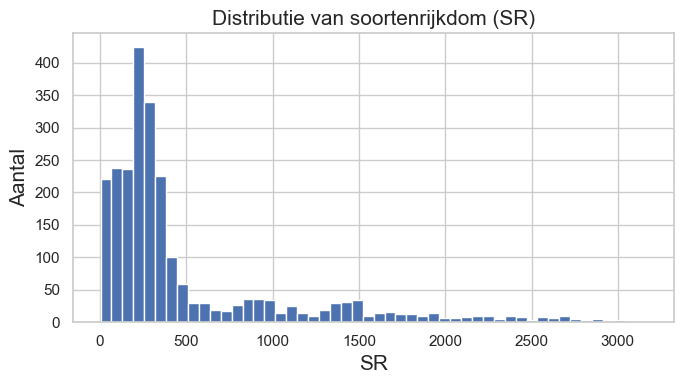

In [58]:
target = "marine_species_richness"
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_merge[target], bins=50, edgecolor="white")
ax.set_xlabel("SR", fontsize = 15)
ax.set_ylabel("Aantal", fontsize = 15)
ax.set_title("Distributie van soortenrijkdom (SR)", fontsize = 15)
plt.tight_layout()
plt.show()

Visualisatie doelvariabele

In [59]:
import plotly.express as px
import plotly.io as pio

fig = px.scatter_geo(
    df_merge,
    lat="lat_deg",
    lon="long_deg",
    color="marine_species_richness",
    hover_name="marine_species_richness",
    projection="natural earth",
    range_color=(0, 3200)
)

fig.update_layout(
    title="Soortenrijkdom (SR)",
    title_font=dict(size=32)
)

fig.update_coloraxes(
    colorbar=dict(
        title=dict(text="SR", font=dict(size=24)),
        tickfont=dict(size=18)
    )
)

fig.show()

### Correlatie berekenen
Variabelen t.o.v. target

In [60]:
corr_to_target = df_merge.corr(method = "pearson")[target].drop(labels = [target]) #correlatie berekenen van alle variabelen tov target en correlatie target met zichzelf laten vallen (is toch gelijk aan 1)
top = corr_to_target.reindex(corr_to_target.abs().sort_values(ascending=False).index) #sorteer van hoog naar laag
top.head(15)


clt_mean      -0.619904
SSTAnMean      0.544092
T_mean         0.536497
tas_mean       0.525619
OxyMean       -0.519140
o2_mean       -0.512114
po4_mean      -0.471536
SBTAnMean      0.451983
no3_mean      -0.423383
par_mean       0.366847
mlotst_mean   -0.343860
dfe_mean       0.332728
LandDist      -0.332080
long_deg       0.294096
si_mean       -0.292360
Name: marine_species_richness, dtype: float64

variabelen t.o.v. elkaar

In [61]:
corr = df_merge.corr(numeric_only=True)

# corr omzetten naar lijst van paren
corr_pairs = corr.abs().unstack()

# zelf-correlaties verwijderen
corr_pairs = corr_pairs[corr_pairs < 1]

# top 10
top_pairs = corr_pairs.sort_values(ascending=False).drop_duplicates().head(10)

print(top_pairs)

T_mean        SSTAnMean        0.999700
o2_mean       OxyMean          0.996973
siconc_mean   IceConAnn        0.992688
T_mean        tas_mean         0.988904
tas_mean      SSTAnMean        0.988185
T_mean        o2_mean          0.984634
SSTAnMean     o2_mean          0.984594
OxyMean       T_mean           0.983702
SSTAnMean     OxyMean          0.983362
SalinityMean  salinity_mean    0.982722
dtype: float64


## Volledig model

Dit model bevat data afkomstig van Aquamaps en Bio-ORACLE

### Target en variabelen selecteren

In [62]:
target = "marine_species_richness"
feature_cols = df_merge.columns.drop(["long_deg", "lat_deg", target]).tolist()

print(feature_cols) #dit zijn de variabelen waarop we ons model gaan baseren

['DepthMean', 'ClimZoneCode', 'SSTAnMean', 'SBTAnMean', 'SalinityMean', 'SalinityBMean', 'PrimProdMean', 'IceConAnn', 'OxyMean', 'OxyBMean', 'LandDist', 'Shelf', 'Slope', 'Abyssal', 'Coral', 'Estuary', 'Seamount', 'chl_mean', 'clt_mean', 'currentdirection_mean', 'currentvelocity_mean', 'dfe_mean', 'kdpar_mean', 'mlotst_mean', 'no3_mean', 'o2_mean', 'par_mean', 'phyc_mean', 'ph_mean', 'po4_mean', 'salinity_mean', 'siconc_mean', 'sithick_mean', 'si_mean', 'tas_mean', 'terrain_characteristics_aspect', 'terrain_characteristics_bea_mean', 'terrain_characteristics_rug', 'terrain_characteristics_slope', 'terrain_characteristics_topo', 'T_mean']


In [63]:
df_model = df_merge[[target] + feature_cols].copy()
print(f"Shape before cleaning: {df_model.shape}")
df_model.head()

Shape before cleaning: (2452, 42)


,marine_species_richness,DepthMean,ClimZoneCode,SSTAnMean,SBTAnMean,SalinityMean,SalinityBMean,PrimProdMean,IceConAnn,OxyMean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
0,44.0,3998.0,5.0,-1.693377,-0.049802,33.934307,34.705566,1.153,0.708033,308.798553,...,0.731921,0.682407,103.700478,-12.067131,10.920937,-3936.972168,66.347260,0.933108,6.854279,-1.602750
1,43.0,4079.0,5.0,-1.697129,-0.070504,33.976231,34.703896,1.141,0.702925,309.091431,...,0.727964,0.742742,104.054313,-11.786772,141.201179,-4093.388916,21.055542,0.320794,-12.930603,-1.620118
2,44.0,4185.0,5.0,-1.658674,-0.071121,33.934555,34.703419,1.120,0.694178,311.400299,...,0.693648,0.713952,102.867443,-11.387081,216.269828,-4160.611328,14.489563,0.228825,5.524109,-1.582915
3,44.0,4231.0,5.0,-1.629549,-0.072501,33.875896,34.703423,1.169,0.679715,313.670135,...,0.693803,0.720227,99.723148,-10.962065,224.836870,-4305.361328,4.413208,0.081748,1.760254,-1.579760
4,45.0,4322.0,5.0,-1.620574,-0.066624,33.789886,34.710335,1.094,0.683326,315.589600,...,0.687315,0.703112,97.156055,-10.534314,300.267603,-4353.527832,10.302124,0.234018,-0.892456,-1.570748


### Ontbrekende waarden verwijderen

In [64]:
# Ontbrekende waarden worden als -9999 aangegeven in de dataset.
df_model.replace(-9999.0, np.nan, inplace=True)
df_model.replace(-9999, np.nan, inplace=True)

missing = df_model.isna().sum() # Ontbrekende waarden tellen.
print("Missing values per column:\n")
print(missing[missing > 0])

df_model.dropna(inplace=True) # Ontbrekende waarden verwijderen.
print(f"\nShape after dropping rows with NaN: {df_merge.shape}")

Missing values per column:

SSTAnMean                           172
SBTAnMean                           172
SalinityMean                        172
SalinityBMean                       172
PrimProdMean                        172
IceConAnn                           172
OxyMean                             172
OxyBMean                            172
chl_mean                            235
clt_mean                            235
currentdirection_mean               235
currentvelocity_mean                235
dfe_mean                            235
kdpar_mean                          237
mlotst_mean                         235
no3_mean                            235
o2_mean                             235
par_mean                            250
phyc_mean                           235
ph_mean                             235
po4_mean                            235
salinity_mean                       235
siconc_mean                         235
sithick_mean                        235
si_mean     

### Data splitten in training en test set

In [65]:
X = df_model[feature_cols]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2026
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

Training samples: 1760
Test samples:     441


### Fitten van een Random Forest model op de training dataset

In [66]:
rf = RandomForestRegressor(
    n_estimators=800,
    max_depth=None,
    min_samples_leaf=1,
    max_features=0.5,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

RandomForestRegressor(max_features=0.5, n_estimators=800, n_jobs=-1,
                      random_state=42)

### Hyperparameters optimaliseren

De bekomen hyperparameters in model hierboven gebruiken

 Code momenteel als markdown

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

#de hyperparameters optimaliseren 
param_grid = {
    "n_estimators": [200, 500, 800],
    "max_depth": [10, 20, 30, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", 0.3, 0.5]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

### Evalueren van rf op training en test set

Moet op beide goed zijn anders is het overgefit op training set

In [67]:
# voorspellingen maken op de test set
y_pred = rf.predict(X_test)

# Evalueren van een aantal metrieken
r2_train = rf.score(X_train, y_train)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Train R² : {r2_train:.4f}")
print(f"Test  R² : {r2:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"\nTrain–test gap: {r2_train - r2:.4f}")

Train R² : 0.9637
Test  R² : 0.7971
RMSE     : 264.6894
MAE      : 151.4064

Train–test gap: 0.1666


### Visualiseren resultaten

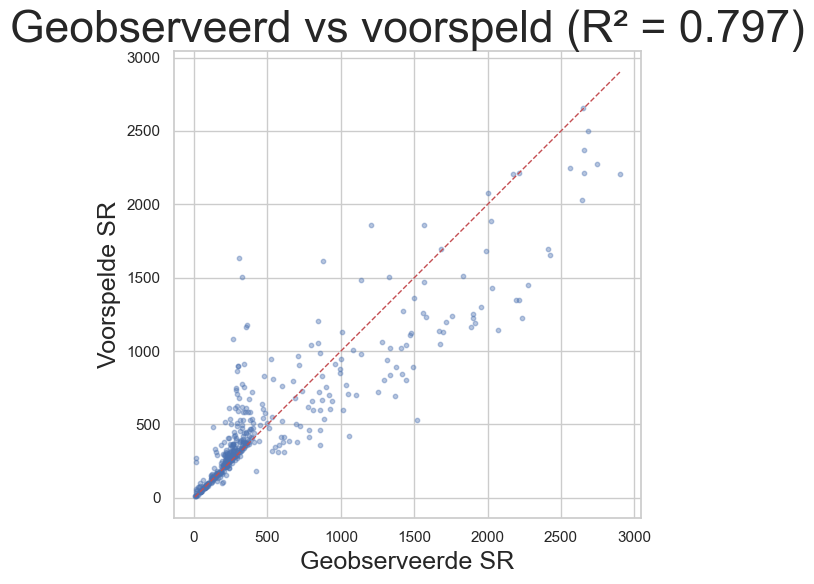

In [68]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, s=10, alpha=0.4)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_xlabel("Geobserveerde SR", fontsize=18)
ax.set_ylabel("Voorspelde SR", fontsize=18)
ax.set_title(f"Geobserveerd vs voorspeld (R² = {r2:.3f})", fontsize=32)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

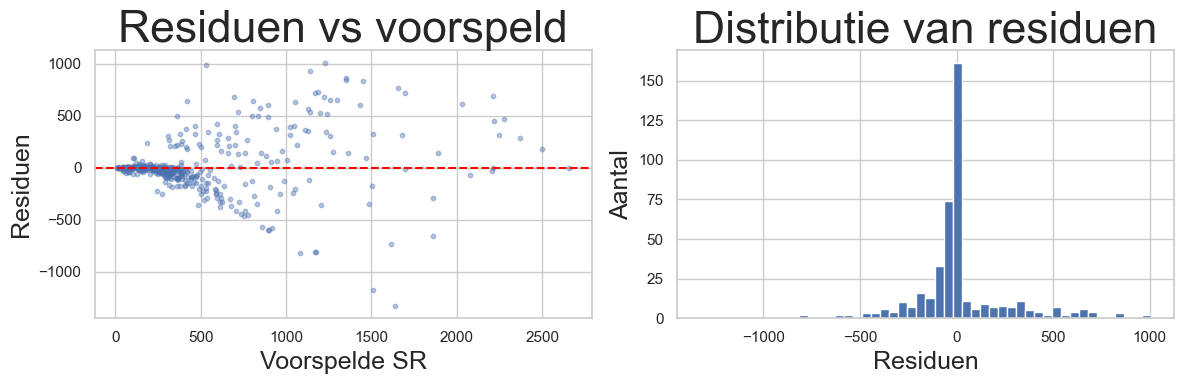

In [69]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred, residuals, s=10, alpha=0.4)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Voorspelde SR", fontsize=18)
axes[0].set_ylabel("Residuen", fontsize=18)
axes[0].set_title("Residuen vs voorspeld", fontsize=32)

axes[1].hist(residuals, bins=50, edgecolor="white")
axes[1].set_xlabel("Residuen", fontsize=18  )
axes[1].set_ylabel("Aantal", fontsize=18)
axes[1].set_title("Distributie van residuen", fontsize=32)

plt.tight_layout()
plt.show()

### Feature importances van gefitte rf

In [70]:
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
top_imp = imp.tail(10)
print(top_imp)

ph_mean          0.031172
OxyMean          0.032998
SalinityBMean    0.033192
LandDist         0.048982
dfe_mean         0.058899
o2_mean          0.062534
si_mean          0.071975
po4_mean         0.073638
tas_mean         0.076501
clt_mean         0.193496
dtype: float64


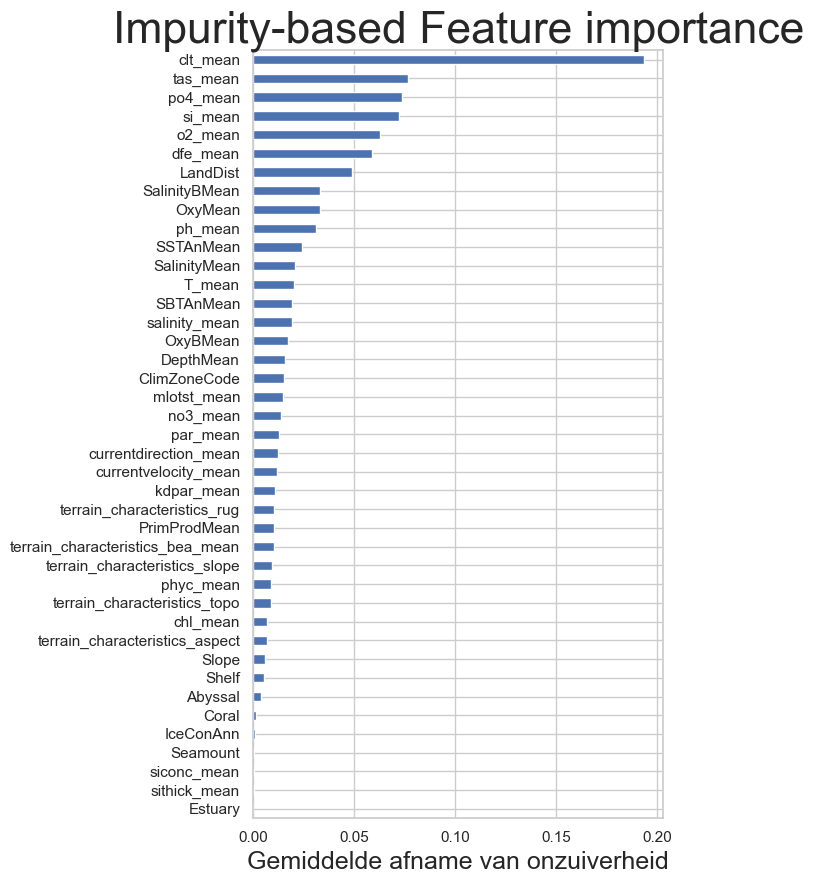

In [71]:
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, 9))
imp.plot.barh(ax=ax)
ax.set_xlabel("Gemiddelde afname van onzuiverheid", fontsize=18)
ax.set_title("Impurity-based Feature importance", fontsize=32)
plt.tight_layout()
plt.show()

### Spatiale crossvalidatie

In [72]:
lat = df_merge.loc[df_model.index, "lat_deg"]
lon = df_merge.loc[df_model.index, "long_deg"]
lat_bin = pd.cut(lat, bins=np.arange(-90, 91, 10), labels=False)
lon_bin = pd.cut(lon, bins=np.arange(-180, 181, 10), labels=False)
spatial_blocks = lat_bin.astype(str) + "_" + lon_bin.astype(str)

print(f"\nSpatial blocks (10°×10° grid): {spatial_blocks.nunique()} unique blocks")

gkf = GroupKFold(n_splits=5)
spatial_cv = cross_val_score(
    rf, X, y, cv=gkf, groups=spatial_blocks, scoring="r2", n_jobs=-1,
)
print("Spatial  5-fold CV R² scores:", np.round(spatial_cv, 4))
print(f"Mean R²: {spatial_cv.mean():.4f}  ±  {spatial_cv.std():.4f}")


Spatial blocks (10°×10° grid): 422 unique blocks
Spatial  5-fold CV R² scores: [0.7247 0.7077 0.6747 0.6857 0.6906]
Mean R²: 0.6967  ±  0.0176


## Model met minder variabelen

Dit model bevat enkel variabelen van Bio-ORACLE. Daarnaast worden de variabelen die niet beschikbaar zijn in de toekomst ook verwijderd. Op dit model wordt ook dimensionaliteitsreductie uitgevoerd.

### Dataframe met enkel Bio-ORACLE

In [73]:
df_bio = df_biooracle
df_bio.columns

Index(['marine_species_richness', 'PD', 'co1_genetic_diversity_mean',
       'long_deg', 'lat_deg', 'chl_max', 'chl_mean', 'chl_min', 'clt_max',
       'clt_mean', 'clt_min', 'currentdirection_max', 'currentdirection_mean',
       'currentdirection_min', 'currentvelocity_ltmax', 'currentvelocity_max',
       'currentvelocity_mean', 'currentvelocity_min', 'dfe_max', 'dfe_mean',
       'dfe_min', 'kdpar_max', 'kdpar_mean', 'kdpar_min', 'mlotst_max',
       'mlotst_mean', 'mlotst_min', 'no3_max', 'no3_mean', 'no3_min', 'o2_max',
       'o2_mean', 'o2_min', 'par_mean', 'par_min', 'phyc_max', 'phyc_mean',
       'phyc_min', 'ph_max', 'ph_mean', 'ph_min', 'po4_max', 'po4_mean',
       'po4_min', 'salinity_ltmax', 'salinity_ltmin', 'salinity_max',
       'salinity_mean', 'salinity_min', 'salinity_range', 'siconc_max',
       'siconc_mean', 'siconc_min', 'sithick_max', 'sithick_mean',
       'sithick_min', 'si_max', 'si_mean', 'si_min', 'tas_max', 'tas_mean',
       'tas_min', 'terrain_charact

Data verwijderen die onnodig is: andere biodiversiteitsmaten, enkel gemiddeldes overhouden

In [74]:
cols_to_drop = (df_bio.filter(regex=r'(?i)(min|max|range)').columns.tolist() + ["PD", "co1_genetic_diversity_mean"])
df_bio = df_bio.drop(cols_to_drop, axis = 1)

df_bio.columns

Index(['marine_species_richness', 'long_deg', 'lat_deg', 'chl_mean',
       'clt_mean', 'currentdirection_mean', 'currentvelocity_mean', 'dfe_mean',
       'kdpar_mean', 'mlotst_mean', 'no3_mean', 'o2_mean', 'par_mean',
       'phyc_mean', 'ph_mean', 'po4_mean', 'salinity_mean', 'siconc_mean',
       'sithick_mean', 'si_mean', 'tas_mean', 'terrain_characteristics_aspect',
       'terrain_characteristics_bea_mean', 'terrain_characteristics_rug',
       'terrain_characteristics_slope', 'terrain_characteristics_topo',
       'T_mean'],
      dtype='object')

Variabelen verwijderen die niet beschikbaar zijn in de toekomst

In [75]:
cols_to_drop = (df_bio.filter(regex=r'(?i)(min|max|range)').columns.tolist() + ["kdpar_mean", "par_mean", "terrain_characteristics_aspect", "terrain_characteristics_bea_mean", "terrain_characteristics_rug", "terrain_characteristics_slope", "terrain_characteristics_topo"])
df_bio = df_bio.drop(cols_to_drop, axis = 1)

df_bio.columns

Index(['marine_species_richness', 'long_deg', 'lat_deg', 'chl_mean',
       'clt_mean', 'currentdirection_mean', 'currentvelocity_mean', 'dfe_mean',
       'mlotst_mean', 'no3_mean', 'o2_mean', 'phyc_mean', 'ph_mean',
       'po4_mean', 'salinity_mean', 'siconc_mean', 'sithick_mean', 'si_mean',
       'tas_mean', 'T_mean'],
      dtype='object')

In [76]:
target_red = "marine_species_richness" # Geselecteerde biodiversiteitsmaat om te voorspellen.
feature_cols_red = df_bio.columns.drop(["long_deg", "lat_deg", "marine_species_richness"]).tolist()

df_red = df_bio[[target_red] + feature_cols_red].copy()
print(f"Shape before cleaning: {df_red.shape}")
df_red.describe()

Shape before cleaning: (2452, 18)


,marine_species_richness,chl_mean,clt_mean,currentdirection_mean,currentvelocity_mean,dfe_mean,mlotst_mean,no3_mean,o2_mean,phyc_mean,ph_mean,po4_mean,salinity_mean,siconc_mean,sithick_mean,si_mean,tas_mean,T_mean
count,2452.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000
mean,510.114600,0.259398,0.447101,152.689401,0.096974,0.000404,48.266381,7.874852,257.423756,1.538574,8.043805,0.673196,34.520979,0.059461,0.070197,14.698095,14.624145,16.382824
std,596.260933,0.215264,0.186835,80.485733,0.096603,0.000829,28.577804,10.287690,53.447055,0.745757,0.025790,0.700528,1.583589,0.173575,0.215610,26.476457,11.465120,10.565343
min,4.000000,0.043151,0.027449,8.444567,0.001367,0.000005,6.990705,0.000422,197.984285,0.554283,7.793579,0.000169,3.213432,0.000000,0.000000,0.656868,-16.241398,-1.838033
25%,176.000000,0.105136,0.271776,74.841409,0.036148,0.000070,29.868310,0.020503,208.600594,1.213635,8.033113,0.090502,33.910668,0.000000,0.000000,1.594731,5.300397,6.396754
50%,273.000000,0.244400,0.450085,138.466769,0.068392,0.000143,41.403713,2.020931,235.609703,1.444429,8.044218,0.381472,34.541424,0.000000,0.000000,2.670603,17.737980,19.306662
75%,499.250000,0.346993,0.613930,233.689689,0.125637,0.000330,56.961308,15.241677,305.790494,1.622265,8.056951,1.198416,35.364977,0.000000,0.000000,13.881882,25.288107,26.387225
max,3167.000000,3.750575,0.785068,315.692114,1.121662,0.009292,199.046201,36.047286,387.724233,13.682373,8.141021,2.234311,38.747336,0.963429,1.794409,121.972284,28.490869,30.261832


Hier nog eens opnieuw de missende waarden verwijderen, want df is weer gemaakt op basis van de kolommen waar die waarden nog niet waren verwijderd. 

In [77]:
df_red.replace(-9999.0, np.nan, inplace=True)
df_red.replace(-9999, np.nan, inplace=True)

missing = df_red.isna().sum()
print("Missende waarden per kolom:\n")
print(missing[missing > 0])

df_red.dropna(inplace=True)
print(f"\nShape after dropping rows with NaN: {df_red.shape}")

Missende waarden per kolom:

chl_mean                 235
clt_mean                 235
currentdirection_mean    235
currentvelocity_mean     235
dfe_mean                 235
mlotst_mean              235
no3_mean                 235
o2_mean                  235
phyc_mean                235
ph_mean                  235
po4_mean                 235
salinity_mean            235
siconc_mean              235
sithick_mean             235
si_mean                  235
tas_mean                 235
T_mean                   235
dtype: int64

Shape after dropping rows with NaN: (2217, 18)


In [78]:
print(df_red.isna().sum().sort_values(ascending=False).head(10))

marine_species_richness    0
chl_mean                   0
tas_mean                   0
si_mean                    0
sithick_mean               0
siconc_mean                0
salinity_mean              0
po4_mean                   0
ph_mean                    0
phyc_mean                  0
dtype: int64


In [79]:
X_red = df_red[feature_cols_red]
y_red = df_red[target_red]


In [80]:
X_red.columns

Index(['chl_mean', 'clt_mean', 'currentdirection_mean', 'currentvelocity_mean',
       'dfe_mean', 'mlotst_mean', 'no3_mean', 'o2_mean', 'phyc_mean',
       'ph_mean', 'po4_mean', 'salinity_mean', 'siconc_mean', 'sithick_mean',
       'si_mean', 'tas_mean', 'T_mean'],
      dtype='object')

### Recursive feature elimination 

RMSE en spatiale cross validatie

In [81]:
# Spatial blocks aanmaken op basis van df_bio
lat_bio = df_bio.loc[df_red.index, "lat_deg"]
lon_bio = df_bio.loc[df_red.index, "long_deg"]
lat_bin_bio = pd.cut(lat_bio, bins=np.arange(-90, 91, 10), labels=False)
lon_bin_bio = pd.cut(lon_bio, bins=np.arange(-180, 181, 10), labels=False)
spatial_blocks_red = lat_bin_bio.astype(str) + "_" + lon_bin_bio.astype(str)

print(f"Spatial blocks (10°x10° grid): {spatial_blocks_red.nunique()} unique blocks")

Spatial blocks (10°x10° grid): 424 unique blocks


Als markdown

from sklearn.feature_selection import RFECV

#### Random Forest
estimator = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

#### RFECV met spatial CV + RMSE
selector = RFECV(
    estimator,
    step=1,
    cv=gkf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

selector.fit(X_red, y_red, groups=spatial_blocks_red)

print(f"Optimal number of features: {selector.n_features_}")

selected_features_RFECV = X_red.columns[selector.support_]
print("Selected features:", list(selected_features_RFECV))

### Dataset met geselecteerde features

In [82]:
selected_features_RFECV = [
  'clt_mean',
  'currentdirection_mean',
  'currentvelocity_mean',
  'dfe_mean',
  'mlotst_mean',
  'no3_mean',
  'o2_mean',
  'phyc_mean',
  'ph_mean',
  'po4_mean',
  'salinity_mean',
  'si_mean',
  'tas_mean',
  'T_mean'
]

### Data splitten in training en test set

In [83]:
X_selected = X_red[selected_features_RFECV]
y_selected = y_red

X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected, y_selected, test_size = 0.2, random_state = 2026
)

print(f"Training set: {X_train_selected.shape[0]}")
print(f"Test set: {X_test_selected.shape[0]}")

Training set: 1773
Test set: 444


### Fitten van een rf model op training set met enkel geselecteerde features

In [84]:
rf_selected_RFECV = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=1,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf_selected_RFECV.fit(X_train_selected, y_train_selected)

# Feature importances
imp = pd.Series(
    rf_selected_RFECV.feature_importances_,
    index=selected_features_RFECV
).sort_values()

print(imp)

currentvelocity_mean     0.021581
currentdirection_mean    0.023409
phyc_mean                0.023844
no3_mean                 0.028798
mlotst_mean              0.040452
salinity_mean            0.053700
ph_mean                  0.056346
T_mean                   0.068727
dfe_mean                 0.069336
po4_mean                 0.078388
o2_mean                  0.094957
tas_mean                 0.096559
si_mean                  0.106559
clt_mean                 0.237342
dtype: float64


### Hyperparameters optimaliseren

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

lat_train = df_bio.loc[X_train_selected.index, "lat_deg"]
lon_train = df_bio.loc[X_train_selected.index, "long_deg"]
lat_bin_train = pd.cut(lat_train, bins=np.arange(-90, 91, 10), labels=False)
lon_bin_train = pd.cut(lon_train, bins=np.arange(-180, 181, 10), labels=False)
spatial_blocks_train = lat_bin_train.astype(str) + "_" + lon_bin_train.astype(str)

rf= RandomForestRegressor(random_state=42)

# de hyperparameters optimaliseren 
param_grid = {
    "n_estimators": [200, 500, 800],
    "max_depth": [10, 20, 30, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", 0.3, 0.5]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=gkf,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train_selected, y_train_selected, groups=spatial_blocks_train)

print(grid.best_params_)

resultaten: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 800}

### Evalueren van rf op training en test set


In [85]:
y_pred_sel = rf_selected_RFECV.predict(X_test_selected)

r2_train_sel = rf_selected_RFECV.score(X_train_selected, y_train_selected)
rmse_sel = np.sqrt(mean_squared_error(y_test_selected, y_pred_sel))
mae_sel = mean_absolute_error(y_test_selected, y_pred_sel)
r2_sel = r2_score(y_test_selected, y_pred_sel)

print(f"Train R²: {r2_train_sel:.4f}")
print(f"Test R²: {r2_sel:.4f}")
print(f"RMSE: {rmse_sel:.4f}")
print(f"MAE: {mae_sel:.4f}")
print(f"\nTrain-test gap: {r2_train_sel - r2_sel:.4f}")

Train R²: 0.9596
Test R²: 0.7150
RMSE: 325.9168
MAE: 174.7462

Train-test gap: 0.2446


### Visualisatie 

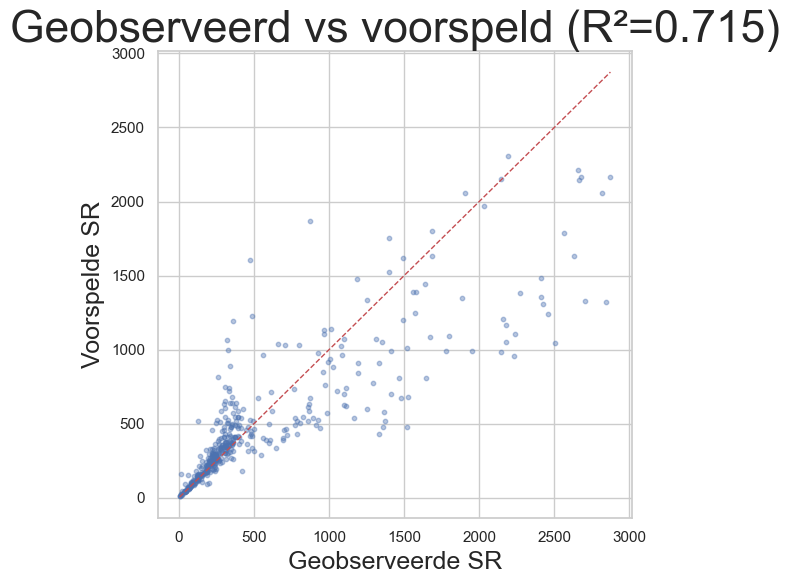

In [86]:
fig, ax = plt.subplots(figsize = (6,6))
ax.scatter(y_test_selected, y_pred_sel, alpha=0.4, s = 10)
lims = [min(y_test_selected.min(), y_pred_sel.min()), max(y_test_selected.max(), y_pred_sel.max())]
ax.plot(lims, lims, 'r--' , linewidth=1)
ax.set_xlabel("Geobserveerde SR", fontsize = 18)
ax.set_ylabel("Voorspelde SR", fontsize = 18)
ax.set_title(f"Geobserveerd vs voorspeld (R²={r2_sel:.3f})", fontsize=32)
plt.tight_layout()
plt.show()

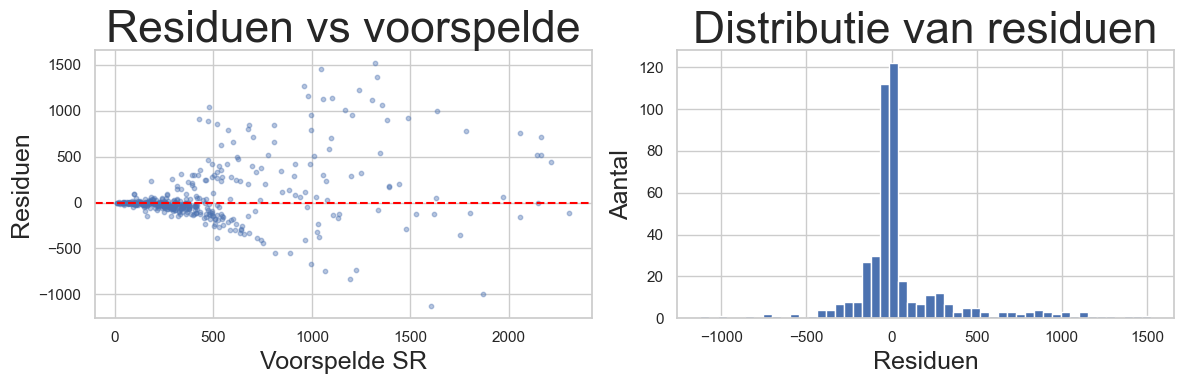

In [87]:
residuals_red = y_test_selected - y_pred_sel

fig, axes = plt.subplots(1,2, figsize = (12,4))

axes[0].scatter(y_pred_sel, residuals_red, alpha=0.4, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Voorspelde SR", fontsize = 18)
axes[0].set_ylabel("Residuen", fontsize = 18) 
axes[0].set_title("Residuen vs voorspelde", fontsize = 32)

axes[1].hist(residuals_red, bins=50, edgecolor='white')
axes[1].set_xlabel("Residuen", fontsize = 18) 
axes[1].set_ylabel("Aantal", fontsize = 18)
axes[1].set_title("Distributie van residuen", fontsize=32)

plt.tight_layout()
plt.show()

### Feature importance

In [88]:
imp_red = pd.Series(rf_selected_RFECV.feature_importances_, index=selected_features_RFECV).sort_values()
top_imp_red = imp_red.tail(10)
print(top_imp_red)

mlotst_mean      0.040452
salinity_mean    0.053700
ph_mean          0.056346
T_mean           0.068727
dfe_mean         0.069336
po4_mean         0.078388
o2_mean          0.094957
tas_mean         0.096559
si_mean          0.106559
clt_mean         0.237342
dtype: float64


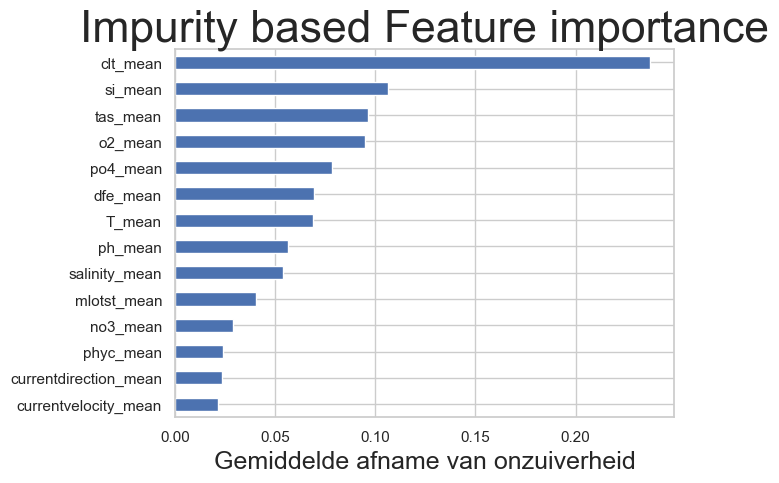

In [89]:
imp_red = pd.Series(rf_selected_RFECV.feature_importances_, index=selected_features_RFECV).sort_values()

fig, ax = plt.subplots(figsize=(7,5))
imp_red.plot.barh(ax=ax)
ax.set_xlabel("Gemiddelde afname van onzuiverheid", fontsize = 18)
ax.set_title("Impurity based Feature importance", fontsize = 32)
plt.tight_layout()
plt.show()

### Spatiale cross validatie

In [90]:
gkf = GroupKFold(n_splits=5)
spatial_cv_red = cross_val_score(
    rf_selected_RFECV, X_selected, y_selected, cv=gkf, groups=spatial_blocks_red, scoring="r2", n_jobs=-1,
)
print("Spatial  5-fold CV R² scores:", np.round(spatial_cv_red, 4))
print(f"Mean R²: {spatial_cv_red.mean():.4f}  ±  {spatial_cv_red.std():.4f}")

Spatial  5-fold CV R² scores: [0.3638 0.7157 0.7038 0.6298 0.7177]
Mean R²: 0.6262  ±  0.1351


## Definitieve model
Nu weten we adhv het model gemaakt van train en test set dat het een goeie performantie heeft. Nu kunnen we het model opnieuw met alle data maken(niet meer opgesplits in train en test). Op die manier gaat er geen informatie verloren.

In [91]:

rf_selected_RFECV.fit(X_selected, y_selected)

# Feature importances
imp = pd.Series(
    rf_selected_RFECV.feature_importances_,
    index=selected_features_RFECV
).sort_values()

print(imp)

currentvelocity_mean     0.022001
phyc_mean                0.026201
currentdirection_mean    0.026321
no3_mean                 0.028179
mlotst_mean              0.033429
salinity_mean            0.052356
T_mean                   0.053508
ph_mean                  0.054339
dfe_mean                 0.074449
po4_mean                 0.083218
o2_mean                  0.097989
tas_mean                 0.099464
si_mean                  0.099923
clt_mean                 0.248623
dtype: float64


## Toekomst

### Toekomstige data inladen

In [92]:
# 50-60
SSP119_50_60 = pd.read_csv('Data/2050-60_SSP119.csv')
SSP245_50_60 = pd.read_csv('Data/2050-60_SSP245.csv')
SSP585_50_60 = pd.read_csv('Data/2050-60_SSP585.csv')
SSP119_50_60.columns

#90-100
SSP119_90_100 = pd.read_csv('Data/2090-2100_SSP119.csv')
SSP245_90_100 = pd.read_csv('Data/2090-2100_SSP245.csv')
SSP585_90_100 = pd.read_csv('Data/2090-2100_SSP585.csv')
SSP119_90_100.columns

Index(['Unnamed: 0', 'chl_mean', 'clt_mean', 'dfe_mean', 'mlotst_mean',
       'no3_mean', 'o2_mean', 'phyc_mean', 'ph_mean', 'po4_mean',
       'siconc_mean', 'sithick_mean', 'si_mean', 'salinity_mean',
       'currentdirection_mean', 'currentvelocity_mean', 'tas_mean', 'T_mean',
       'long_deg', 'lat_deg'],
      dtype='object')

Kolommen selecteren van de selected features

In [93]:
# 50-60
SR_SSP119_50_60 = SSP119_50_60[['long_deg', 'lat_deg'] + selected_features_RFECV]
SR_SSP245_50_60 = SSP245_50_60[['long_deg', 'lat_deg'] + selected_features_RFECV]
SR_SSP585_50_60 = SSP585_50_60[['long_deg', 'lat_deg'] + selected_features_RFECV]


#90-100
SR_SSP119_90_100 = SSP119_90_100[['long_deg', 'lat_deg'] + selected_features_RFECV]
SR_SSP245_90_100 = SSP245_90_100[['long_deg', 'lat_deg'] + selected_features_RFECV]
SR_SSP585_90_100 = SSP585_90_100[['long_deg', 'lat_deg'] + selected_features_RFECV]

### Toekomst voorspellingen SSP119

#### Voorspelling jaren 50-60

In [94]:
X_SSP119_50_60 = SR_SSP119_50_60[selected_features_RFECV] 
y_SSP119_50_60 = rf_selected_RFECV.predict(X_SSP119_50_60)

SR_SSP119_50_60["SR"] =  y_SSP119_50_60

ValueError: Input X contains NaN.
RandomForestRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

Distributie plotten

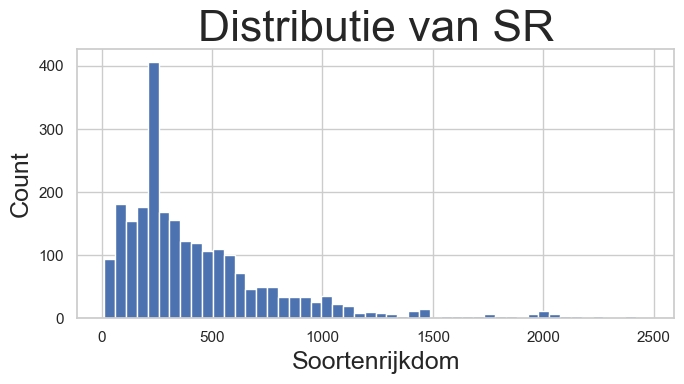

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(SR_SSP119_50_60["SR"], bins=50, edgecolor="white")
ax.set_xlabel("Soortenrijkdom", fontsize=18)
ax.set_ylabel("Count", fontsize=18)
ax.set_title("Distributie van SR", fontsize=32)
plt.tight_layout()
plt.show()

Kaart plotten

In [ ]:
import plotly.express as px
import plotly.io as pio

In [ ]:
fig_SR_SSP119_50_60 = px.scatter_geo(
    SR_SSP119_50_60,
    lat="lat_deg",
    lon="long_deg",
    color="SR",   # kleurt de punten op basis van biodiversiteit
    hover_name="SR",  
    projection="natural earth",    # mooie wereldkaart
    title= "Soortenrijkdom volgens SSP119 (2050-2060)",
    range_color = (0, 3200)
)

fig_SR_SSP119_50_60.update_layout(
    title=dict(
        font=dict(size=32)
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "SR"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)


fig_SR_SSP119_50_60.show()

Kaart met verschil plotten 

In [ ]:
SR_SSP119_50_60["Relatief verschil"] = (SR_SSP119_50_60["SR"] - df_bio["marine_species_richness"])/df_bio["marine_species_richness"]
fig_SR_SSP119_50_60_verschil = px.scatter_geo(
    SR_SSP119_50_60,
    lat="lat_deg",
    lon="long_deg",
    color="Relatief verschil",   # kleurt de punten op basis van het verschil in genetische diversiteit
    hover_name="SR",  
    projection="natural earth",    # mooie wereldkaart
    title = "Verschil SR (SSP119 (2050-2060) vs Huidige situatie)"
)

fig_SR_SSP119_50_60_verschil.update_layout(
    title=dict(
        font=dict(size=32),
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "SR"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)

fig_SR_SSP119_50_60_verschil.show()

C:\Users\norah\AppData\Local\Temp\ipykernel_14252\752372254.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Voorspelling jaren 90-100

In [ ]:
X_SSP119_90_100 = SR_SSP119_90_100[selected_features_RFECV] 
y_SSP119_90_100 = rf_selected_RFECV.predict(X_SSP119_90_100)

SR_SSP119_90_100["SR"] =  y_SSP119_90_100


C:\Users\norah\AppData\Local\Temp\ipykernel_14252\2355503056.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Distributie plotten

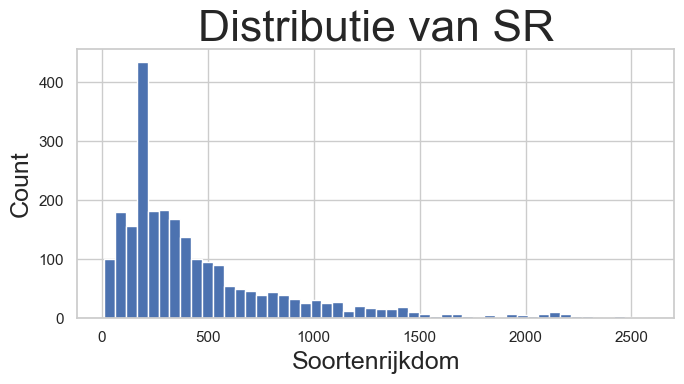

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(SR_SSP119_90_100["SR"], bins=50, edgecolor="white")
ax.set_xlabel("Soortenrijkdom", fontsize=18)
ax.set_ylabel("Count", fontsize=18)
ax.set_title("Distributie van SR", fontsize=32)
plt.tight_layout()
plt.show()

Kaart plotten

In [ ]:
fig_SR_SSP119_90_100 = px.scatter_geo(
    SR_SSP119_90_100,
    lat="lat_deg",
    lon="long_deg",
    color="SR",   # kleurt de punten op basis van biodiversiteit
    hover_name="SR",  
    projection="natural earth",    # mooie wereldkaart
    title = "Soortenrijkdom volgens SSP119 (2090-2100)",
    range_color = (0, 3200)
)

fig_SR_SSP119_90_100.update_layout(
    title=dict(
        font=dict(size=32),
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "SR"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)

fig_SR_SSP119_90_100.show()

Kaart met verschil plotten

In [ ]:
SR_SSP119_90_100["Relatief verschil"] = (SR_SSP119_90_100["SR"] - df_bio["marine_species_richness"])/df_bio["marine_species_richness"]
fig_SR_SSP119_90_100_verschil = px.scatter_geo(
    SR_SSP119_90_100,
    lat="lat_deg",
    lon="long_deg",
    color="Relatief verschil",   # kleurt de punten op basis van het verschil in soortenrijkdom
    hover_name="SR",  
    projection="natural earth",    # mooie wereldkaart
    title = "Verschil SR (SSP119 (2090-2100) vs Huidige situatie)"
)

fig_SR_SSP119_90_100_verschil.update_layout(
    title=dict(
        font=dict(size=32),
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "SR"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)

fig_SR_SSP119_90_100_verschil.show()

C:\Users\norah\AppData\Local\Temp\ipykernel_14252\2327874875.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



### Toekomst voorspellingen SSP245

#### Voorspelling jaren 50-60

In [ ]:
X_SSP245_50_60 = SR_SSP245_50_60[selected_features_RFECV] 
y_SSP245_50_60 = rf_selected_RFECV.predict(X_SSP245_50_60)

SR_SSP245_50_60["SR"] =  y_SSP245_50_60

C:\Users\norah\AppData\Local\Temp\ipykernel_14252\1538674238.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Distributie plotten

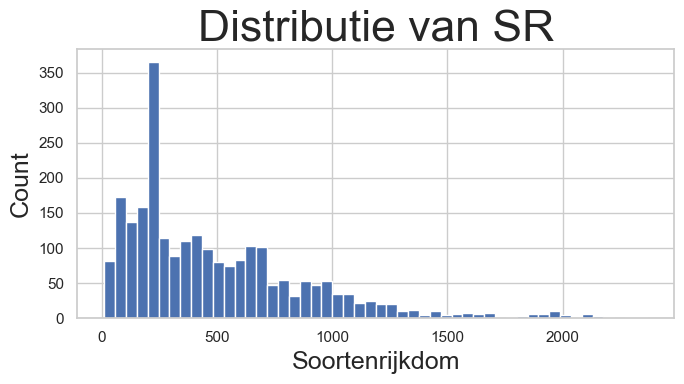

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(SR_SSP245_50_60["SR"], bins=50, edgecolor="white")
ax.set_xlabel("Soortenrijkdom", fontsize=18)
ax.set_ylabel("Count", fontsize=18)
ax.set_title("Distributie van SR", fontsize=32)
plt.tight_layout()
plt.show()

Kaart plotten

In [ ]:
fig_SR_SSP245_50_60 = px.scatter_geo(
    SR_SSP245_50_60,
    lat="lat_deg",
    lon="long_deg",
    color="SR",   # kleurt de punten op basis van biodiversiteit
    hover_name="SR",  
    projection="natural earth",    # mooie wereldkaart
    title= "Soortenrijkdom volgens SSP245 (2050-2060)",
    range_color = (0, 3200)
)

fig_SR_SSP245_50_60.update_layout(
    title=dict(
        font=dict(size=32)
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "SR"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)


fig_SR_SSP245_50_60.show()

Kaart met verschil plotten

In [ ]:
SR_SSP245_50_60["Relatief verschil"] = (SR_SSP245_50_60["SR"] - df_bio["marine_species_richness"])/df_bio["marine_species_richness"]
fig_SR_SSP245_50_60_verschil = px.scatter_geo(
    SR_SSP245_50_60,
    lat="lat_deg",
    lon="long_deg",
    color="Relatief verschil",   # kleurt de punten op basis van het verschil in genetische diversiteit
    hover_name="SR",  
    projection="natural earth",    # mooie wereldkaart
    title = "Verschil SR (SSP245 (2050-2060) vs Huidige situatie)"
)

fig_SR_SSP245_50_60_verschil.update_layout(
    title=dict(
        font=dict(size=32),
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "SR"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)

fig_SR_SSP245_50_60_verschil.show()

C:\Users\norah\AppData\Local\Temp\ipykernel_14252\1445739189.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



#### Voorspelling 90-100

In [ ]:
X_SSP245_90_100 = SR_SSP245_90_100[selected_features_RFECV] 
y_SSP245_90_100 = rf_selected_RFECV.predict(X_SSP245_90_100)

SR_SSP245_90_100["SR"] =  y_SSP245_90_100

C:\Users\norah\AppData\Local\Temp\ipykernel_14252\2722270808.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Distributie plotten

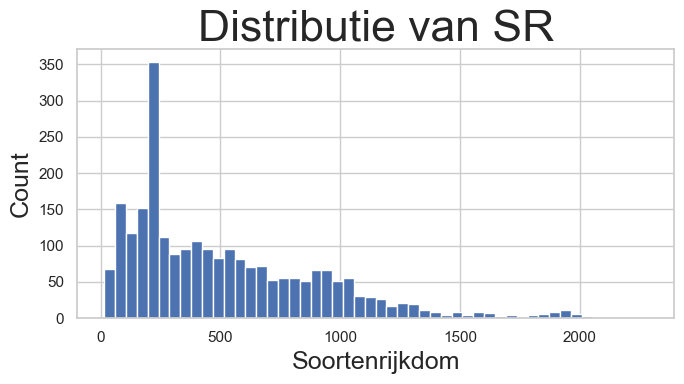

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(SR_SSP245_90_100["SR"], bins=50, edgecolor="white")
ax.set_xlabel("Soortenrijkdom", fontsize=18)
ax.set_ylabel("Count", fontsize=18)
ax.set_title("Distributie van SR", fontsize=32)
plt.tight_layout()
plt.show()

Kaart plotten

In [ ]:
fig_SR_SSP245_90_100 = px.scatter_geo(
    SR_SSP245_90_100,
    lat="lat_deg",
    lon="long_deg",
    color="SR",   # kleurt de punten op basis van biodiversiteit
    hover_name="SR",  
    projection="natural earth",    # mooie wereldkaart
    title = "Soortenrijkdom volgens SSP245 (2090-2100)",
    range_color = (0, 3200)
)

fig_SR_SSP245_90_100.update_layout(
    title=dict(
        font=dict(size=32),
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "SR"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)

fig_SR_SSP245_90_100.show()

Kaart met verschil plotten

In [ ]:
SR_SSP245_90_100["Relatief verschil"] = (SR_SSP245_90_100["SR"] - df_bio["marine_species_richness"])/df_bio["marine_species_richness"]
fig_SR_SSP245_90_100_verschil = px.scatter_geo(
    SR_SSP245_90_100,
    lat="lat_deg",
    lon="long_deg",
    color="Relatief verschil",   # kleurt de punten op basis van het verschil in soortenrijkdom
    hover_name="SR",  
    projection="natural earth",    # mooie wereldkaart
    title = "Verschil SR (SSP245 (2090-2100) vs Huidige situatie)"
)

fig_SR_SSP245_90_100_verschil.update_layout(
    title=dict(
        font=dict(size=32),
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "SR"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)

fig_SR_SSP245_90_100_verschil.show()

C:\Users\norah\AppData\Local\Temp\ipykernel_14252\751284957.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



### Toekomst voorspellingen SSP585

#### Voorspelling jaren 50-60


In [ ]:
X_SSP585_50_60 = SR_SSP585_50_60[selected_features_RFECV] 
y_SSP585_50_60 = rf_selected_RFECV.predict(X_SSP585_50_60)

SR_SSP585_50_60["SR"] =  y_SSP585_50_60

C:\Users\norah\AppData\Local\Temp\ipykernel_14252\3950274274.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Distributie plotten

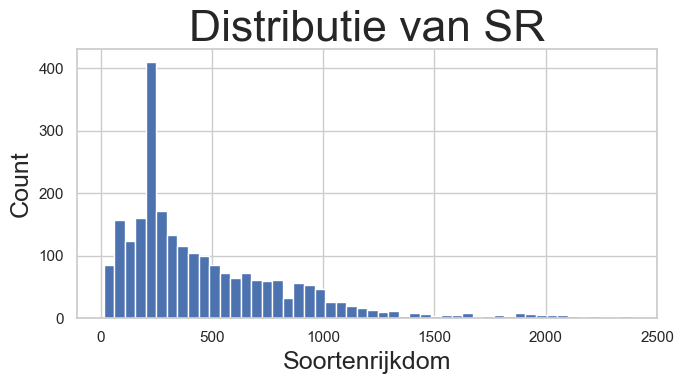

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(SR_SSP585_50_60["SR"], bins=50, edgecolor="white")
ax.set_xlabel("Soortenrijkdom", fontsize=18)
ax.set_ylabel("Count", fontsize=18)
ax.set_title("Distributie van SR", fontsize=32)
plt.tight_layout()
plt.show()

Kaart plotten

In [ ]:
fig_SR_SSP585_50_60 = px.scatter_geo(
    SR_SSP585_50_60,
    lat="lat_deg",
    lon="long_deg",
    color="SR",   # kleurt de punten op basis van biodiversiteit
    hover_name="SR",  
    projection="natural earth",    # mooie wereldkaart
    title= "Soortenrijkdom volgens SSP585 (2050-2060)",
    range_color = (0, 3200)
)

fig_SR_SSP585_50_60.update_layout(
    title=dict(
        font=dict(size=32)
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "SR"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)


fig_SR_SSP585_50_60.show()

Kaart met verschil plotten

In [ ]:
SR_SSP585_50_60["Relatief verschil"] = (SR_SSP585_50_60["SR"] - df_bio["marine_species_richness"])/df_bio["marine_species_richness"]
fig_SR_SSP585_50_60_verschil = px.scatter_geo(
    SR_SSP585_50_60,
    lat="lat_deg",
    lon="long_deg",
    color="Relatief verschil",   # kleurt de punten op basis van het verschil in genetische diversiteit
    hover_name="SR",  
    projection="natural earth",    # mooie wereldkaart
    title = "Verschil SR (SSP585 (2050-2060) vs Huidige situatie)"
)

fig_SR_SSP585_50_60_verschil.update_layout(
    title=dict(
        font=dict(size=32),
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "SR"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)

fig_SR_SSP585_50_60_verschil.show()

C:\Users\norah\AppData\Local\Temp\ipykernel_14252\4121659405.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



#### Voorspelling 90-100

In [ ]:
X_SSP585_90_100 = SR_SSP585_90_100[selected_features_RFECV] 
y_SSP585_90_100 = rf_selected_RFECV.predict(X_SSP585_90_100)

SR_SSP585_90_100["SR"] =  y_SSP585_90_100

C:\Users\norah\AppData\Local\Temp\ipykernel_14252\231509437.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Distributie plotten

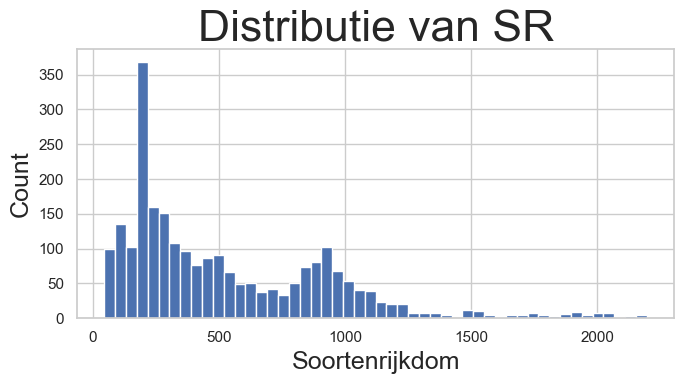

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(SR_SSP585_90_100["SR"], bins=50, edgecolor="white")
ax.set_xlabel("Soortenrijkdom", fontsize=18)
ax.set_ylabel("Count", fontsize=18)
ax.set_title("Distributie van SR", fontsize=32)
plt.tight_layout()
plt.show()

Kaart plotten

In [ ]:
fig_SR_SSP585_90_100 = px.scatter_geo(
    SR_SSP585_90_100,
    lat="lat_deg",
    lon="long_deg",
    color="SR",   # kleurt de punten op basis van biodiversiteit
    hover_name="SR",  
    projection="natural earth",    # mooie wereldkaart
    title = "Soortenrijkdom volgens SSP585 (2090-2100)",
    range_color = (0, 3200)
)

fig_SR_SSP585_90_100.update_layout(
    title=dict(
        font=dict(size=32),
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "SR"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)

fig_SR_SSP585_90_100.show()

Kaart met verschil plotten

In [ ]:
SR_SSP585_90_100["Relatief verschil"] = (SR_SSP585_90_100["SR"] - df_bio["marine_species_richness"])/df_bio["marine_species_richness"]
fig_SR_SSP585_90_100_verschil = px.scatter_geo(
    SR_SSP585_90_100,
    lat="lat_deg",
    lon="long_deg",
    color="Relatief verschil",   # kleurt de punten op basis van het verschil in soortenrijkdom
    hover_name="SR",  
    projection="natural earth",    # mooie wereldkaart
    title = "Verschil SR (SSP585 (2090-2100) vs Huidige situatie)"
)

fig_SR_SSP585_90_100_verschil.update_layout(
    title=dict(
        font=dict(size=32),
    ),
    coloraxis_colorbar=dict(
        title=dict(font=dict(size=24)),  # titel "SR"
        tickfont=dict(size=18)            # cijfers op de kleurenschaal
    )
)

fig_SR_SSP585_90_100_verschil.show()

C:\Users\norah\AppData\Local\Temp\ipykernel_14252\2851496113.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

